# Chapter 03: The Geometry of the Gauss Map

Source orientation: printed pp. 136-219; PDF pp. 152-235. This notebook is a standalone, visualization-first lesson for Chapter 3. It uses the local PDF only to orient terminology and order of ideas; all prose, code, diagrams, checks, and artifacts here are original.

**Chapter goal.** Treat the Gauss map as a measurable curvature sensor: the derivative of the normal field becomes the shape operator, its eigenvectors become principal directions, its determinant and trace become Gaussian and mean curvature, and its examples explain vector fields, ruled surfaces, and minimal surfaces.


## Source-Oriented Route

The assigned chapter moves from local normal fields to global examples. The computational route here follows the same landmarks without copying the source presentation.

1. Build the Gauss map `N: S -> S^2` and measure how a small surface patch changes its normal area.
2. Read `S = -dN` as a tangent-plane linear map, then diagonalize it to get principal directions and principal curvatures.
3. Use the first and second fundamental forms as matrices: `S = I^{-1} II`, `K = det(S)`, and `H = trace(S)/2`.
4. Visualize normal curvature, asymptotic directions, conjugate directions, and the Dupin indicatrix on tangent planes.
5. Use vector fields as integral-curve machinery for principal and asymptotic nets.
6. Stress-test intuition with ruled, developable, and minimal surfaces: straight rulings do not force flatness, and `H = 0` does not force `K = 0`.

The self-adjoint appendix is integrated as a proof scaffold: because the shape operator is self-adjoint for the surface metric, principal directions with distinct principal curvatures are orthogonal in that metric.


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sympy as sp
from IPython.display import display


def find_book_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
            return candidate
    raise RuntimeError("Could not locate the course root")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact

UNIT = "chapter-03"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ARTIFACT_ROOT / "figures"
HTML_DIR = ARTIFACT_ROOT / "interactive"
CHECK_DIR = ARTIFACT_ROOT / "checks"
TABLE_DIR = ARTIFACT_ROOT / "tables"
for directory in (FIG_DIR, HTML_DIR, CHECK_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

artifact_registry: dict[str, Path] = {}
artifact_notes: dict[str, str] = {}


def book_relative(path: str | Path) -> str:
    path = Path(path).resolve()
    return path.relative_to(BOOK_ROOT.resolve()).as_posix()


def register_artifact(key: str, path: str | Path, note: str) -> Path:
    path = Path(path)
    artifact_registry[key] = path
    artifact_notes[key] = note
    return path


def write_json(path: Path, data: dict, key: str, note: str) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")
    return register_artifact(key, path, note)


def save_mpl(fig, path: Path, key: str, note: str, *, dpi: int = 180) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    return register_artifact(key, path, note)


def save_plotly(fig, path: Path, key: str, note: str) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.write_html(path, include_plotlyjs="cdn", full_html=True)
    return register_artifact(key, path, note)


def save_table(df: pd.DataFrame, path: Path, key: str, note: str) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    return register_artifact(key, path, note)

print(f"BOOK_ROOT = {BOOK_ROOT}")
print(f"ARTIFACT_ROOT = {book_relative(ARTIFACT_ROOT)}")


BOOK_ROOT = D:\Geometry\Differential-Geometry-of-Curves-and-Surfaces
ARTIFACT_ROOT = artifacts/chapter-03


## Computational Translation Guide

| Chapter object | Computational object | What to inspect |
| --- | --- | --- |
| Oriented surface patch `x(u,v)` | arrays of points, tangent vectors, and unit normals | whether normals vary slowly, rapidly, or collapse in one direction |
| Gauss map `N` | map from sampled surface points to the unit sphere | signed normal-area change versus surface-area change |
| Shape operator | matrix `S = I^{-1} II` acting on tangent coordinates | eigenvectors, eigenvalues, determinant, trace |
| Principal directions | metric-orthogonal eigenvectors of `S` | directions where normal curvature is extremal |
| Gaussian curvature `K` | `det(S)` and Gauss-map area ratio | sign: elliptic, hyperbolic, parabolic, planar |
| Mean curvature `H` | `trace(S)/2` with orientation sign | whether principal bendings balance |
| Vector field | tangent vector assignment plus integral curves | whether directions integrate into curvature-line or asymptotic nets |
| Ruled/minimal examples | Plotly surfaces plus residual checks | straight rulings, zero `K`, zero `H`, and their differences |


## Symbolic Baseline: A Surface Graph at One Point

A local graph is the smallest lab for the chapter. At the origin of

`z = (a x^2 + b y^2)/2`,

the tangent metric is the identity and the second fundamental form is diagonal. The two parameters `a` and `b` are therefore the principal curvatures for the upward normal. The point is elliptic when `ab > 0`, hyperbolic when `ab < 0`, parabolic when exactly one is zero, and planar when both vanish. This model will be used repeatedly below as a controlled curvature dial.


In [2]:
a, b, theta = sp.symbols("a b theta", real=True)
I0 = sp.eye(2)
II0 = sp.Matrix([[a, 0], [0, b]])
S0 = I0.inv() * II0
K0 = sp.factor(S0.det())
H0 = sp.factor(sp.trace(S0) / 2)
normal_curvature = sp.factor((sp.Matrix([sp.cos(theta), sp.sin(theta)]).T * II0 * sp.Matrix([sp.cos(theta), sp.sin(theta)]))[0])

symbolic_checks = {
    "model": "z = (a*x^2 + b*y^2)/2 at the origin, upward normal",
    "shape_operator": str(S0),
    "K_equals_det_S": str(sp.Eq(K0, a * b)),
    "H_equals_half_trace_S": str(sp.Eq(H0, (a + b) / 2)),
    "normal_curvature_clock": str(normal_curvature),
    "principal_curvatures": ["a", "b"],
}
symbolic_path = write_json(
    CHECK_DIR / "symbolic-curvature-identities.json",
    symbolic_checks,
    "symbolic_identities",
    "Exact graph-model identities for S, K, H, and normal curvature.",
)

print(json.dumps(symbolic_checks, indent=2))


{
  "model": "z = (a*x^2 + b*y^2)/2 at the origin, upward normal",
  "shape_operator": "Matrix([[a, 0], [0, b]])",
  "K_equals_det_S": "True",
  "H_equals_half_trace_S": "True",
  "normal_curvature_clock": "a*cos(theta)**2 + b*sin(theta)**2",
  "principal_curvatures": [
    "a",
    "b"
  ]
}


## Proof Scaffold: Why Eigenvectors Matter

The source chapter proves that the differential of the Gauss map is self-adjoint with respect to the first fundamental form, then uses the self-adjoint appendix to justify principal directions. The diagram below turns that proof dependency into a local checklist: the metric and the normal derivative combine to make a symmetric bilinear form, and symmetry is what gives real principal curvatures and metric-orthogonal principal directions.


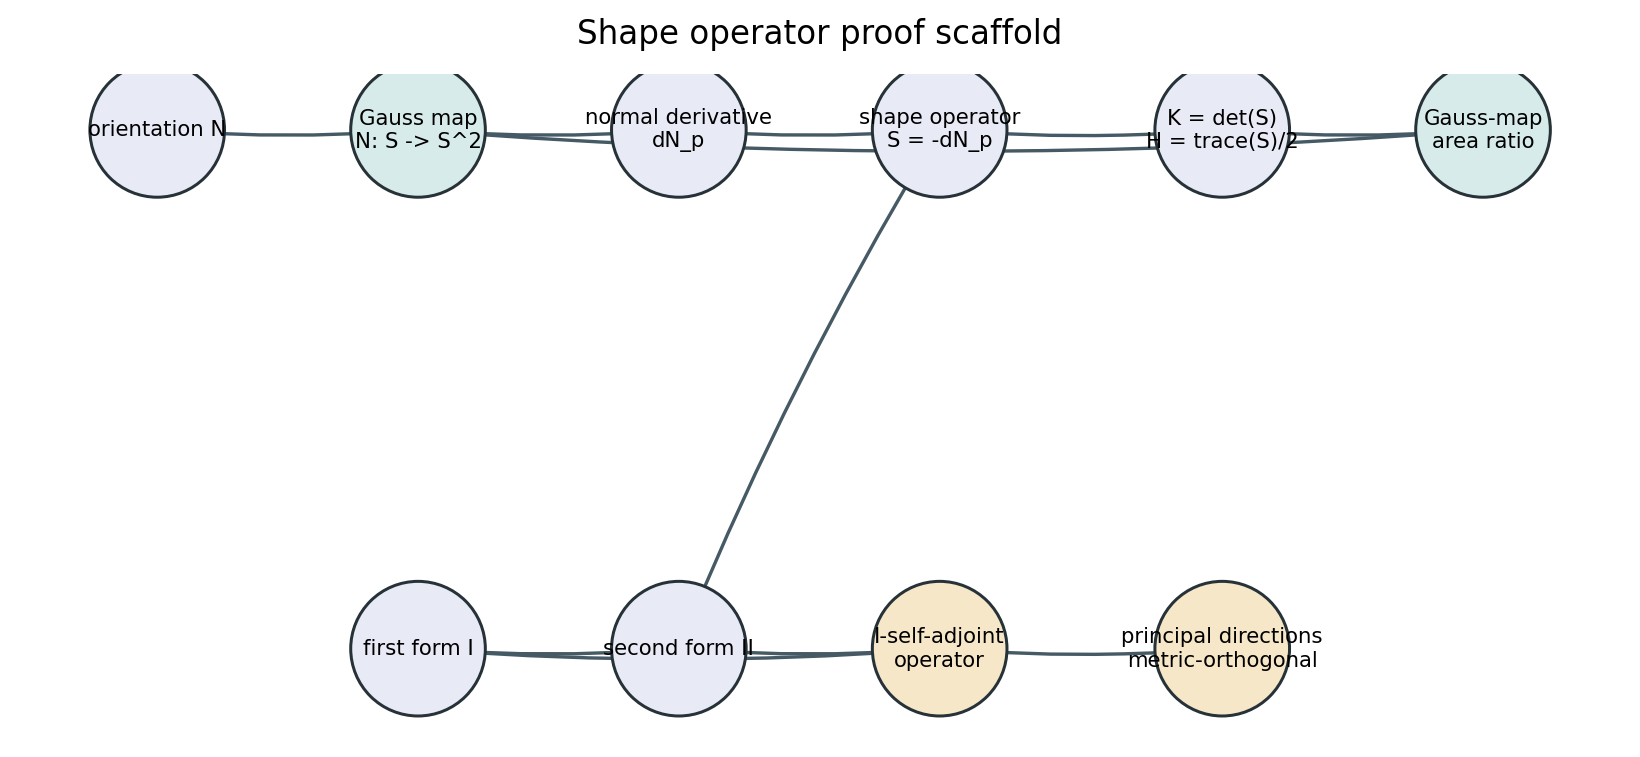

In [3]:
G = nx.DiGraph()
node_labels = {
    "orientation": "orientation N",
    "gauss": "Gauss map\nN: S -> S^2",
    "dN": "normal derivative\ndN_p",
    "shape": "shape operator\nS = -dN_p",
    "metric": "first form I",
    "second": "second form II",
    "self": "I-self-adjoint\noperator",
    "eigen": "principal directions\nmetric-orthogonal",
    "curv": "K = det(S)\nH = trace(S)/2",
    "area": "Gauss-map\narea ratio",
}
for node in node_labels:
    G.add_node(node)
G.add_edges_from([
    ("orientation", "gauss"),
    ("gauss", "dN"),
    ("dN", "shape"),
    ("metric", "second"),
    ("shape", "second"),
    ("second", "self"),
    ("metric", "self"),
    ("self", "eigen"),
    ("shape", "curv"),
    ("curv", "area"),
    ("gauss", "area"),
])
pos = {
    "orientation": (0.0, 1.0),
    "gauss": (1.2, 1.0),
    "dN": (2.4, 1.0),
    "shape": (3.6, 1.0),
    "metric": (1.2, 0.0),
    "second": (2.4, 0.0),
    "self": (3.6, 0.0),
    "eigen": (4.9, 0.0),
    "curv": (4.9, 1.0),
    "area": (6.1, 1.0),
}
fig, ax = plt.subplots(figsize=(11.5, 4.8))
colors = ["#d7ecea" if n in {"gauss", "area"} else "#f6e7c8" if n in {"self", "eigen"} else "#e8eaf6" for n in G.nodes]
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, edgecolors="#263238", node_size=2900, linewidths=1.2)
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=18, width=1.35, edge_color="#455a64", connectionstyle="arc3,rad=0.04")
nx.draw_networkx_labels(G, pos, labels=node_labels, ax=ax, font_size=8.5, font_family="DejaVu Sans")
ax.set_title("Shape operator proof scaffold", fontsize=13, pad=12)
ax.set_axis_off()
pipeline_path = save_mpl(
    fig,
    FIG_DIR / "self-adjoint-shape-operator-pipeline.png",
    "self_adjoint_pipeline",
    "Proof-state diagram connecting Gauss map, shape operator, self-adjointness, and curvature invariants.",
)
display_artifact(pipeline_path, width=820)


## Gauss Map as an Area-Distortion Sensor

For a torus, the normal at `(u,v)` is easy to see and easy to measure. The surface area density is `r(R + r cos v)`. The signed area density of the normal image on the unit sphere is `cos v`. Their ratio is the Gaussian curvature

`K(v) = cos(v) / (r (R + r cos(v)))`.

The HTML scene lets you rotate the torus and the normal image together. The static ledger below is the invariant check: `K dA = signed dA_N`. Where this quantity changes sign, the Gauss map reverses one tangent direction.


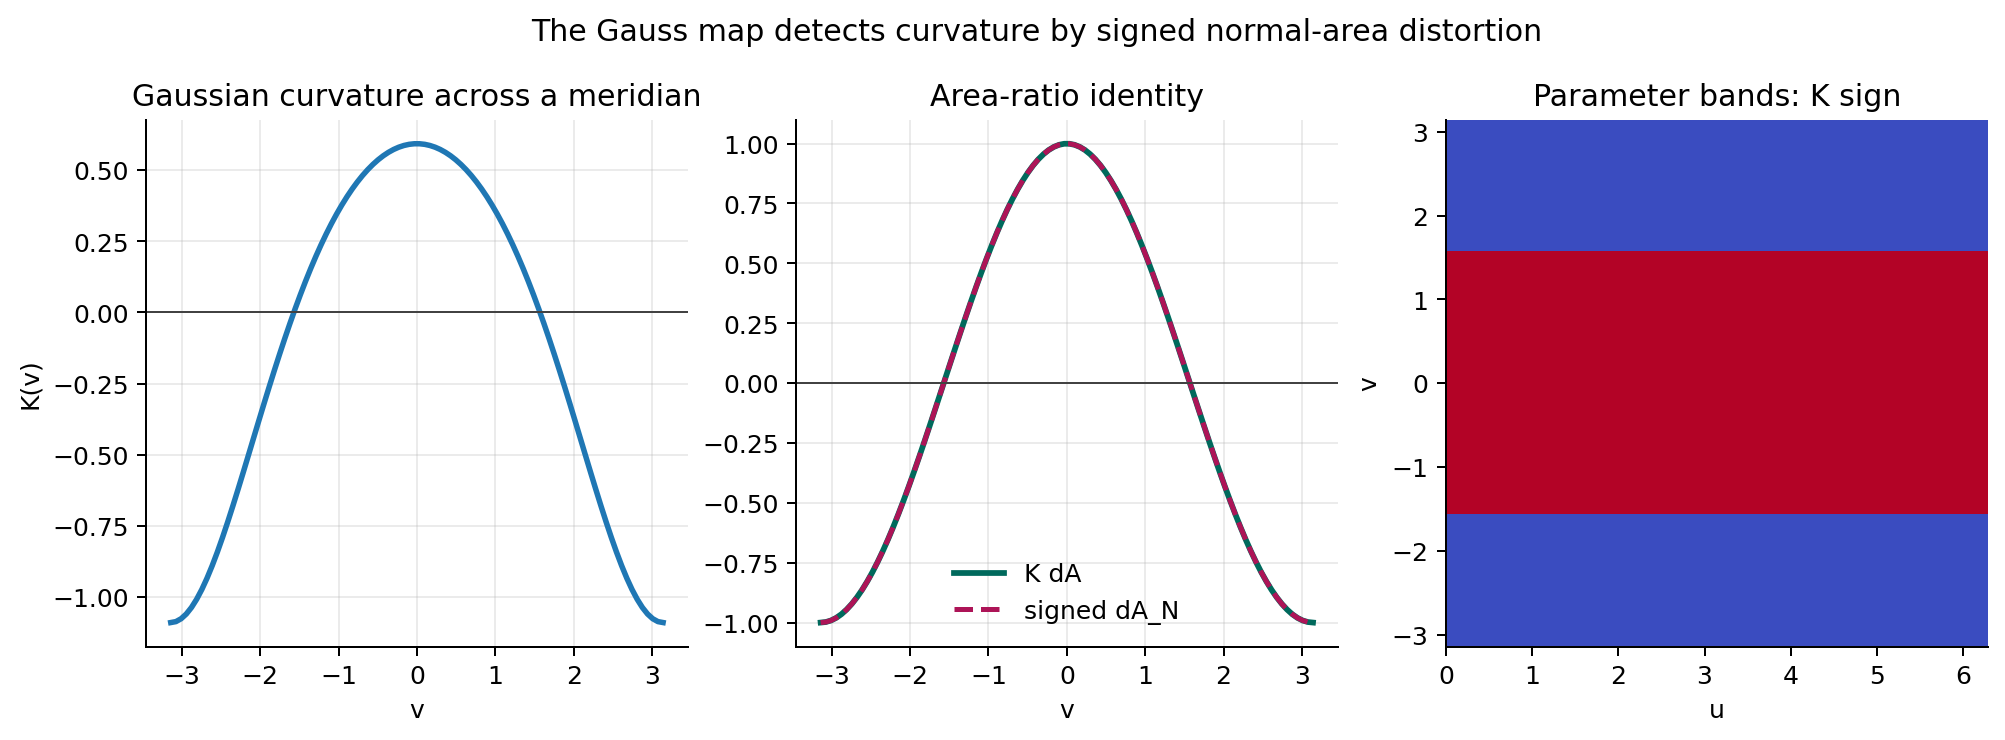

In [4]:
def torus_data(R: float = 2.1, r: float = 0.62, nu: int = 96, nv: int = 96):
    u = np.linspace(0, 2 * np.pi, nu)
    v = np.linspace(-np.pi, np.pi, nv)
    U, V = np.meshgrid(u, v, indexing="ij")
    X = (R + r * np.cos(V)) * np.cos(U)
    Y = (R + r * np.cos(V)) * np.sin(U)
    Z = r * np.sin(V)
    NX = np.cos(V) * np.cos(U)
    NY = np.cos(V) * np.sin(U)
    NZ = np.sin(V)
    K = np.cos(V) / (r * (R + r * np.cos(V)))
    H = -(R + 2 * r * np.cos(V)) / (2 * r * (R + r * np.cos(V)))
    area_density = r * (R + r * np.cos(V))
    signed_normal_area_density = np.cos(V)
    return U, V, X, Y, Z, NX, NY, NZ, K, H, area_density, signed_normal_area_density

U, V, X, Y, Z, NX, NY, NZ, K_torus, H_torus, dA_torus, dA_normal_signed = torus_data()
area_identity_residual = np.max(np.abs(K_torus * dA_torus - dA_normal_signed))


def separated_segments(points_a, points_b):
    xs, ys, zs = [], [], []
    for p, q in zip(points_a, points_b):
        xs += [p[0], q[0], None]
        ys += [p[1], q[1], None]
        zs += [p[2], q[2], None]
    return xs, ys, zs


sample = (slice(0, None, 12), slice(0, None, 12))
P = np.column_stack([X[sample].ravel(), Y[sample].ravel(), Z[sample].ravel()])
N = np.column_stack([NX[sample].ravel(), NY[sample].ravel(), NZ[sample].ravel()])
segments = separated_segments(P, P + 0.32 * N)

su = np.linspace(0, np.pi, 48)
sv = np.linspace(0, 2 * np.pi, 48)
SU, SV = np.meshgrid(su, sv, indexing="ij")
SX = np.sin(SU) * np.cos(SV)
SY = np.sin(SU) * np.sin(SV)
SZ = np.cos(SU)

fig3d = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=("torus colored by K", "normal image on S^2"),
)
lim = float(np.nanmax(np.abs(K_torus)))
fig3d.add_trace(
    go.Surface(x=X, y=Y, z=Z, surfacecolor=K_torus, colorscale="RdBu", cmin=-lim, cmax=lim, showscale=True, colorbar={"title": "K", "len": 0.65}),
    row=1,
    col=1,
)
fig3d.add_trace(
    go.Scatter3d(x=segments[0], y=segments[1], z=segments[2], mode="lines", line={"color": "black", "width": 3}, name="sample normals", showlegend=False),
    row=1,
    col=1,
)
fig3d.add_trace(
    go.Surface(x=SX, y=SY, z=SZ, opacity=0.16, colorscale=[[0, "#cfd8dc"], [1, "#cfd8dc"]], showscale=False, name="unit sphere"),
    row=1,
    col=2,
)
fig3d.add_trace(
    go.Scatter3d(
        x=NX[sample].ravel(),
        y=NY[sample].ravel(),
        z=NZ[sample].ravel(),
        mode="markers",
        marker={"size": 4, "color": K_torus[sample].ravel(), "colorscale": "RdBu", "cmin": -lim, "cmax": lim},
        name="N(u,v)",
        showlegend=False,
    ),
    row=1,
    col=2,
)
fig3d.update_layout(
    title="Gauss map as curvature sensor on a torus",
    height=560,
    margin={"l": 0, "r": 0, "t": 60, "b": 0},
    scene={"aspectmode": "data"},
    scene2={"aspectmode": "data"},
)
torus_html = save_plotly(
    fig3d,
    HTML_DIR / "torus-gauss-map-curvature-sensor.html",
    "torus_gauss_map_html",
    "Interactive torus and unit-sphere normal image colored by Gaussian curvature.",
)

v_line = V[0, :]
K_line = K_torus[0, :]
area_line = dA_torus[0, :]
normal_line = dA_normal_signed[0, :]
fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.8))
axes[0].plot(v_line, K_line, color="#1f77b4", lw=2.2)
axes[0].axhline(0, color="#424242", lw=0.8)
axes[0].set_title("Gaussian curvature across a meridian")
axes[0].set_xlabel("v")
axes[0].set_ylabel("K(v)")
axes[0].grid(alpha=0.25)

axes[1].plot(v_line, K_line * area_line, label="K dA", lw=2.3, color="#00695c")
axes[1].plot(v_line, normal_line, "--", label="signed dA_N", lw=2.0, color="#ad1457")
axes[1].axhline(0, color="#424242", lw=0.8)
axes[1].set_title("Area-ratio identity")
axes[1].set_xlabel("v")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.25)

sign_image = np.sign(K_torus).T
axes[2].imshow(sign_image, origin="lower", aspect="auto", extent=[0, 2 * np.pi, -np.pi, np.pi], cmap="coolwarm", vmin=-1, vmax=1)
axes[2].set_title("Parameter bands: K sign")
axes[2].set_xlabel("u")
axes[2].set_ylabel("v")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("The Gauss map detects curvature by signed normal-area distortion", y=1.03)
ledger_path = save_mpl(
    fig,
    FIG_DIR / "gauss-map-area-distortion.png",
    "gauss_area_ledger",
    "Static check that torus Gaussian curvature equals signed Gauss-map area density divided by surface area density.",
)

torus_checks = {
    "R": 2.1,
    "r": 0.62,
    "max_abs_signed_area_identity": float(area_identity_residual),
    "K_outer_equator": float(1 / (0.62 * (2.1 + 0.62))),
    "K_inner_equator": float(-1 / (0.62 * (2.1 - 0.62))),
    "K_changes_sign_at_v": ["pi/2", "3*pi/2"],
}
torus_check_path = write_json(
    CHECK_DIR / "torus-gauss-map-checks.json",
    torus_checks,
    "torus_gauss_map_checks",
    "Numerical checks for torus Gauss-map area distortion and curvature signs.",
)

display_artifact(ledger_path, width=880)
display_artifact(torus_html, height=520)


## Shape Operator and Principal Directions

The shape operator is not a scalar attached to a point; it is a linear map on the tangent plane. A vector is principal when the normal derivative sends it back along the same tangent direction. The next figure uses the graph saddle `z = (1.2 x^2 - 0.8 y^2)/2`, where the coordinate axes are already principal. One direction bends upward and the transverse direction bends downward; their product is negative and their average records the oriented mean bending.


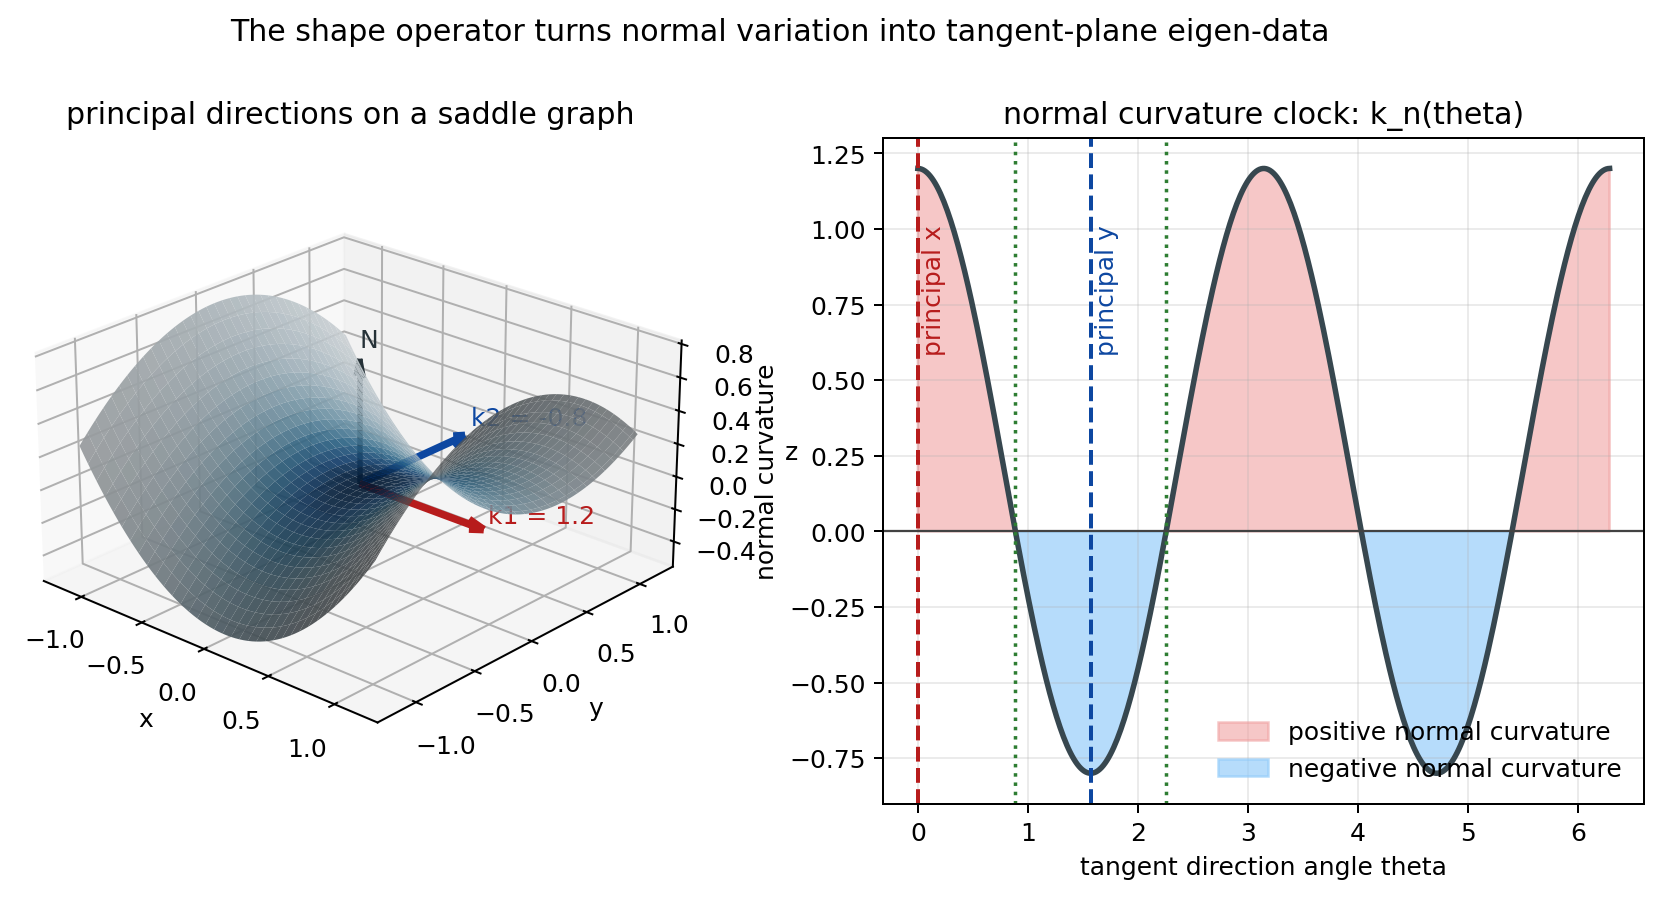

In [5]:
def graph_shape_data(a_value: float, b_value: float, x0: float, y0: float):
    fx = a_value * x0
    fy = b_value * y0
    w = math.sqrt(1 + fx * fx + fy * fy)
    I = np.array([[1 + fx * fx, fx * fy], [fx * fy, 1 + fy * fy]], dtype=float)
    II = np.array([[a_value / w, 0.0], [0.0, b_value / w]], dtype=float)
    S = np.linalg.solve(I, II)
    K = float(np.linalg.det(S))
    H = float(np.trace(S) / 2)
    vals, vecs = np.linalg.eig(S)
    order = np.argsort(vals)
    vals = vals[order]
    vecs = vecs[:, order]
    metric_cross = float(vecs[:, 0].T @ I @ vecs[:, 1])
    return {"I": I, "II": II, "S": S, "K": K, "H": H, "eigenvalues": vals, "eigenvectors": vecs, "metric_cross": metric_cross}


x = np.linspace(-1.15, 1.15, 70)
y = np.linspace(-1.15, 1.15, 70)
Xg, Yg = np.meshgrid(x, y, indexing="ij")
a_s, b_s = 1.2, -0.8
Zg = 0.5 * (a_s * Xg**2 + b_s * Yg**2)
Kg = (a_s * b_s) / (1 + (a_s * Xg) ** 2 + (b_s * Yg) ** 2) ** 2
shape_origin = graph_shape_data(a_s, b_s, 0.0, 0.0)

fig = plt.figure(figsize=(12, 4.8))
ax3 = fig.add_subplot(1, 2, 1, projection="3d")
kg_lim = float(np.max(np.abs(Kg)))
norm = TwoSlopeNorm(vmin=-kg_lim, vcenter=0.0, vmax=kg_lim)
ax3.plot_surface(Xg, Yg, Zg, facecolors=plt.cm.RdBu_r(norm(Kg)), rstride=2, cstride=2, linewidth=0, antialiased=True, alpha=0.92)
ax3.quiver(0, 0, 0, 0.95, 0, 0, color="#b71c1c", linewidth=3, arrow_length_ratio=0.12)
ax3.quiver(0, 0, 0, 0, 0.95, 0, color="#0d47a1", linewidth=3, arrow_length_ratio=0.12)
ax3.quiver(0, 0, 0, 0, 0, 0.75, color="#263238", linewidth=2.2, arrow_length_ratio=0.15)
ax3.text(0.98, 0, 0.05, "k1 = 1.2", color="#b71c1c")
ax3.text(0, 1.0, 0.05, "k2 = -0.8", color="#0d47a1")
ax3.text(0, 0, 0.82, "N", color="#263238")
ax3.set_title("principal directions on a saddle graph")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("z")
ax3.view_init(elev=24, azim=-48)
ax3.set_box_aspect((1, 1, 0.55))

ax = fig.add_subplot(1, 2, 2)
theta_vals = np.linspace(0, 2 * np.pi, 400)
kn = a_s * np.cos(theta_vals) ** 2 + b_s * np.sin(theta_vals) ** 2
ax.plot(theta_vals, kn, color="#37474f", lw=2.2)
ax.fill_between(theta_vals, 0, kn, where=kn >= 0, color="#ef9a9a", alpha=0.55, label="positive normal curvature")
ax.fill_between(theta_vals, 0, kn, where=kn < 0, color="#90caf9", alpha=0.65, label="negative normal curvature")
for angle, label, color in [(0, "principal x", "#b71c1c"), (np.pi / 2, "principal y", "#0d47a1")]:
    ax.axvline(angle, color=color, lw=1.6, ls="--")
    ax.text(angle + 0.04, ax.get_ylim()[1] * 0.78, label, color=color, rotation=90, va="top")
zero_angles = [math.atan(math.sqrt(a_s / abs(b_s))), math.pi - math.atan(math.sqrt(a_s / abs(b_s)))]
for angle in zero_angles:
    ax.axvline(angle, color="#2e7d32", lw=1.4, ls=":")
ax.axhline(0, color="#424242", lw=0.9)
ax.set_title("normal curvature clock: k_n(theta)")
ax.set_xlabel("tangent direction angle theta")
ax.set_ylabel("normal curvature")
ax.legend(frameon=False, loc="lower right")
ax.grid(alpha=0.25)
fig.suptitle("The shape operator turns normal variation into tangent-plane eigen-data", y=1.02)
shape_path = save_mpl(
    fig,
    FIG_DIR / "shape-operator-principal-directions.png",
    "shape_operator_principal_directions",
    "Saddle graph visual showing principal directions, normal, and normal-curvature clock.",
)

shape_checks = {
    "model": "z = (1.2*x^2 - 0.8*y^2)/2 at the origin",
    "principal_curvatures": [float(a_s), float(b_s)],
    "K": float(shape_origin["K"]),
    "H": float(shape_origin["H"]),
    "normal_curvature_zero_angles_rad": [float(value) for value in zero_angles],
}
shape_check_path = write_json(
    CHECK_DIR / "shape-operator-principal-directions.json",
    shape_checks,
    "shape_operator_checks",
    "Principal curvature and normal-curvature zero direction checks for the saddle graph.",
)

display_artifact(shape_path, width=880)


## Dupin Indicatrix and Asymptotic Directions

The Dupin indicatrix is a tangent-plane picture of the second fundamental form. It separates three local types. Elliptic points give ellipses and no asymptotic direction. Hyperbolic points give hyperbola branches, and their asymptotes are exactly the directions of zero normal curvature. Parabolic points collapse one principal curvature to zero, leaving a single asymptotic direction.


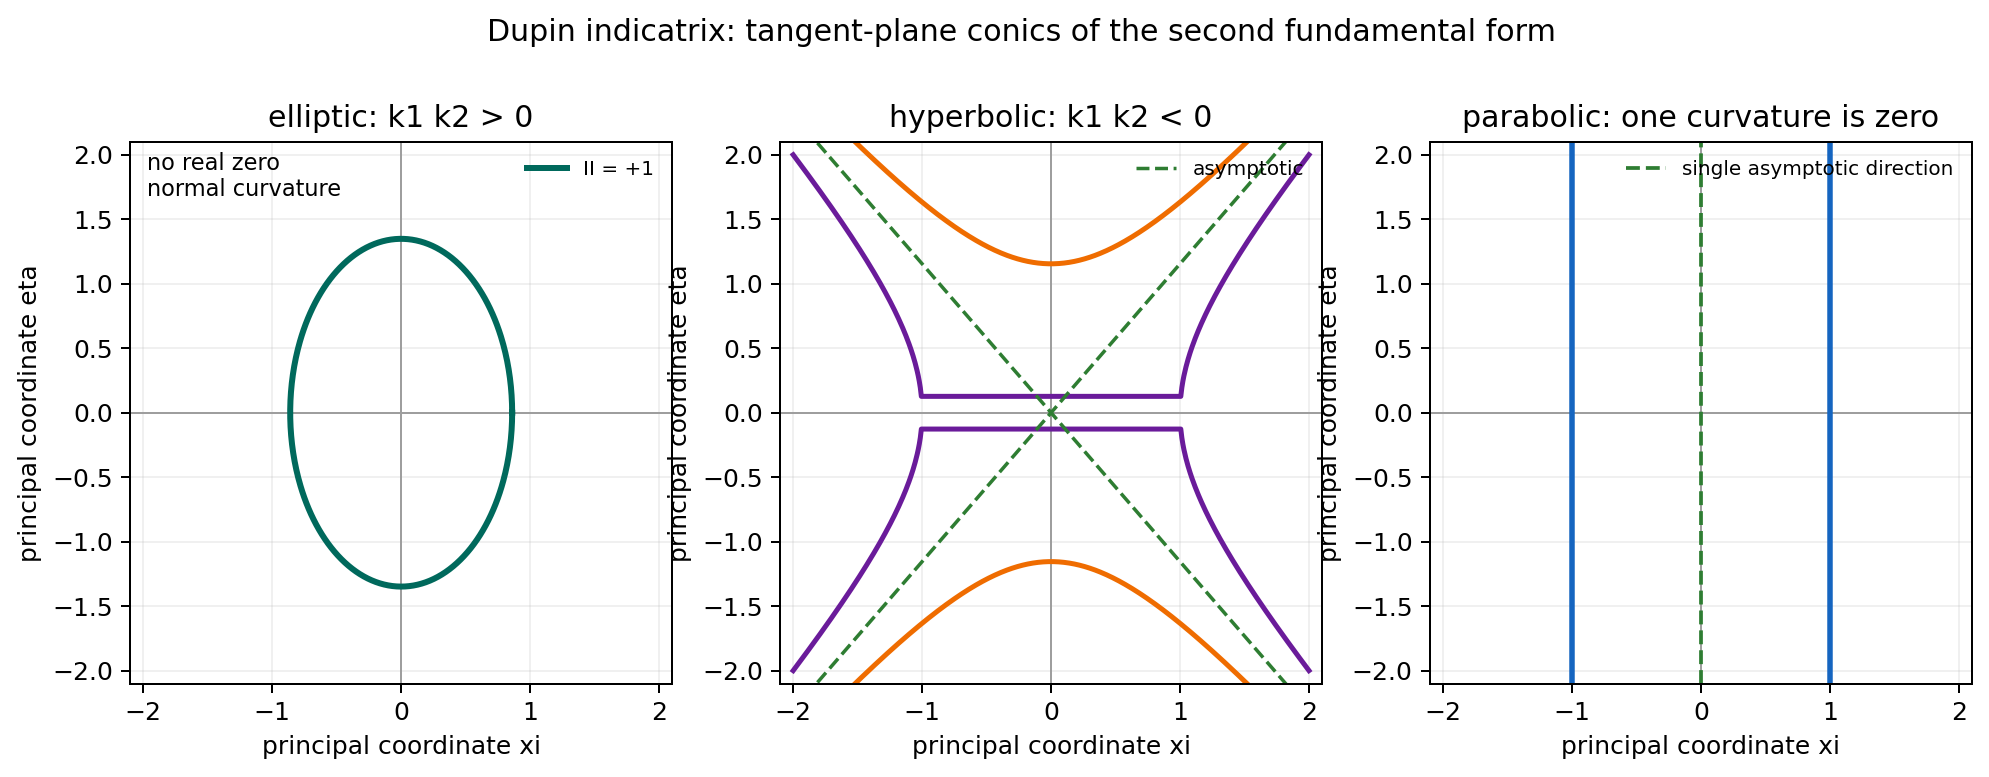

In [6]:
def plot_dupin(ax, k1: float, k2: float, title: str):
    ax.axhline(0, color="#9e9e9e", lw=0.8)
    ax.axvline(0, color="#9e9e9e", lw=0.8)
    t = np.linspace(0, 2 * np.pi, 500)
    if k1 * k2 > 0:
        x = np.cos(t) / math.sqrt(abs(k1))
        y = np.sin(t) / math.sqrt(abs(k2))
        ax.plot(x, y, color="#00695c", lw=2.4, label="II = +1")
        ax.text(0.03, 0.90, "no real zero\nnormal curvature", transform=ax.transAxes, fontsize=9)
    elif k1 * k2 < 0:
        xs = np.linspace(-2.0, 2.0, 500)
        for sign, color in [(1, "#6a1b9a"), (-1, "#ef6c00")]:
            numerator = sign - k1 * xs**2
            ys_sq = numerator / k2
            mask = ys_sq >= 0
            ys = np.sqrt(np.maximum(ys_sq, 0))
            ax.plot(xs[mask], ys[mask], color=color, lw=2.0)
            ax.plot(xs[mask], -ys[mask], color=color, lw=2.0)
        slope = math.sqrt(abs(k1 / k2))
        ax.plot(xs, slope * xs, "--", color="#2e7d32", lw=1.4, label="asymptotic")
        ax.plot(xs, -slope * xs, "--", color="#2e7d32", lw=1.4)
    elif abs(k1) > 1e-12:
        c = 1 / math.sqrt(abs(k1))
        ax.axvline(c, color="#1565c0", lw=2.2)
        ax.axvline(-c, color="#1565c0", lw=2.2)
        ax.axvline(0, color="#2e7d32", lw=1.5, ls="--", label="single asymptotic direction")
    elif abs(k2) > 1e-12:
        c = 1 / math.sqrt(abs(k2))
        ax.axhline(c, color="#1565c0", lw=2.2)
        ax.axhline(-c, color="#1565c0", lw=2.2)
        ax.axhline(0, color="#2e7d32", lw=1.5, ls="--", label="single asymptotic direction")
    else:
        ax.text(0.5, 0.5, "planar point", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-2.1, 2.1)
    ax.set_ylim(-2.1, 2.1)
    ax.set_xlabel("principal coordinate xi")
    ax.set_ylabel("principal coordinate eta")
    ax.grid(alpha=0.18)
    ax.legend(frameon=False, loc="upper right", fontsize=8)


fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.1))
plot_dupin(axes[0], 1.35, 0.55, "elliptic: k1 k2 > 0")
plot_dupin(axes[1], 1.0, -0.75, "hyperbolic: k1 k2 < 0")
plot_dupin(axes[2], 1.0, 0.0, "parabolic: one curvature is zero")
fig.suptitle("Dupin indicatrix: tangent-plane conics of the second fundamental form", y=1.03)
dupin_path = save_mpl(
    fig,
    FIG_DIR / "dupin-indicatrix-asymptotic-directions.png",
    "dupin_indicatrix",
    "Tangent-plane conic view of elliptic, hyperbolic, and parabolic points with asymptotic directions.",
)

dupin_checks = {
    "elliptic_has_asymptotic_directions": False,
    "hyperbolic_asymptotic_slopes": [float(math.sqrt(1.0 / 0.75)), float(-math.sqrt(1.0 / 0.75))],
    "parabolic_single_asymptotic_direction": True,
}
dupin_check_path = write_json(
    CHECK_DIR / "dupin-indicatrix-checks.json",
    dupin_checks,
    "dupin_checks",
    "Checks for asymptotic directions represented in the Dupin indicatrix figure.",
)

display_artifact(dupin_path, width=880)


## Vector Fields: Directions Become Curves

Chapter 3 uses vector fields to turn a direction rule into integral curves. Two direction fields matter here. Principal direction fields integrate to lines of curvature when the field is regular enough. Asymptotic direction fields integrate to curves whose normal curvature vanishes. The parameter-domain view below is intentional: it separates the vector-field mechanism from the 3D rendering.


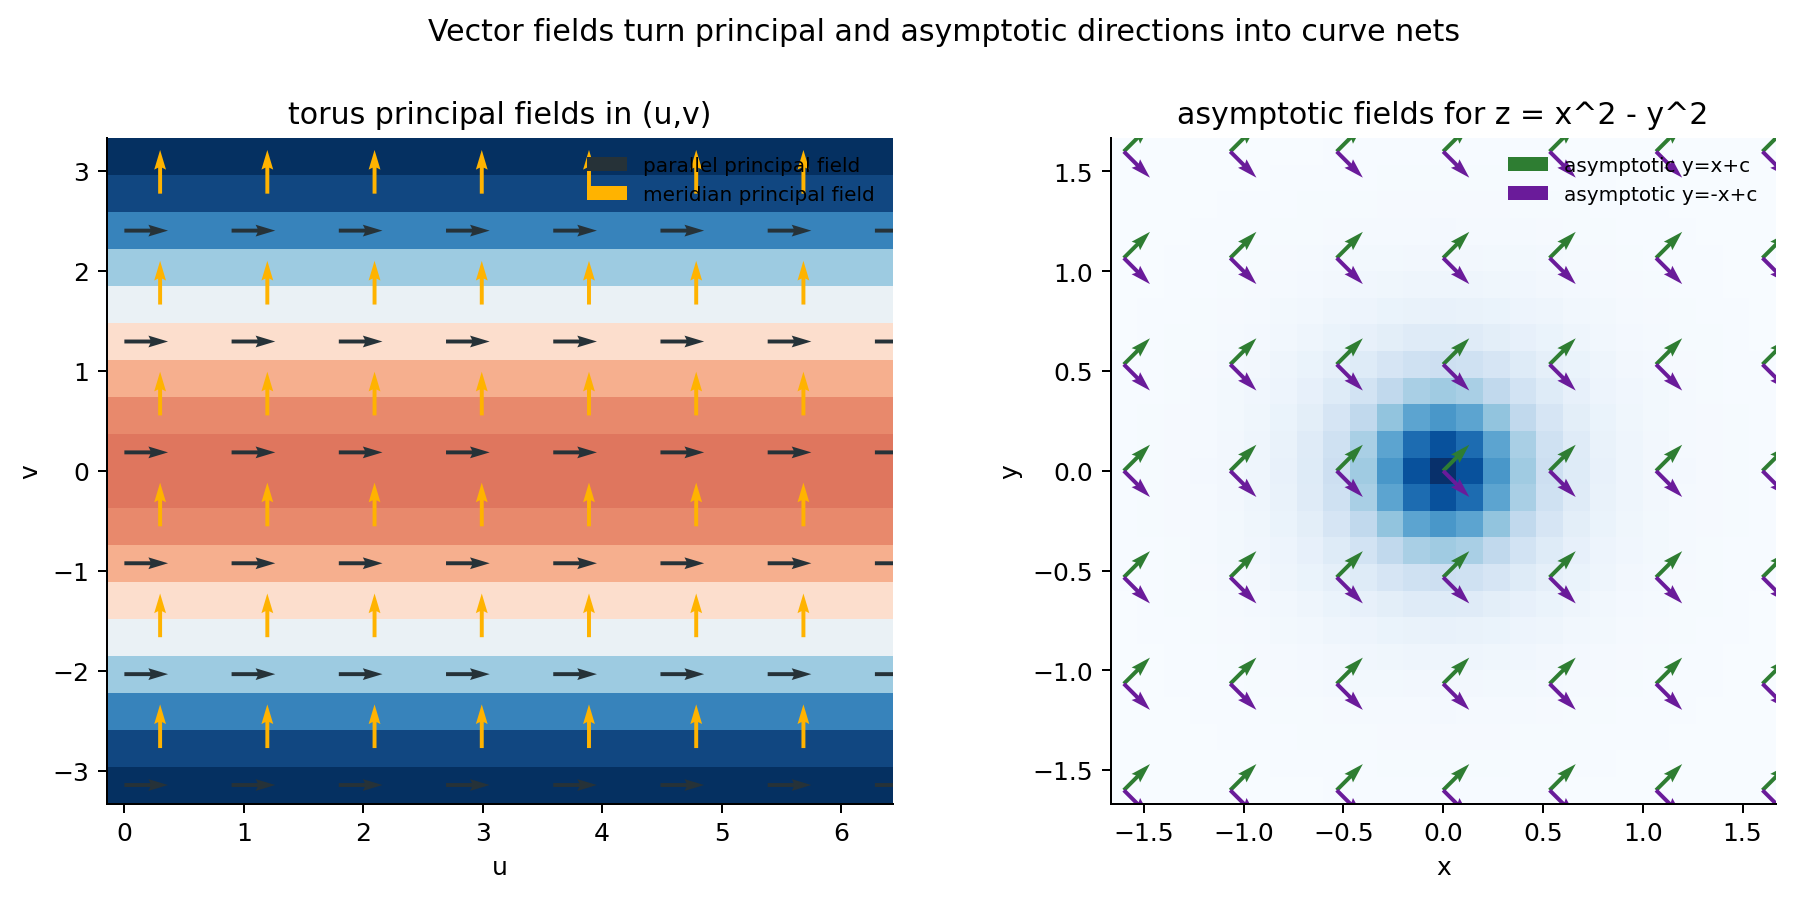

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8))

u = np.linspace(0, 2 * np.pi, 22)
v = np.linspace(-np.pi, np.pi, 18)
UU, VV = np.meshgrid(u, v, indexing="xy")
R_vis, r_vis = 2.1, 0.62
K_param = np.cos(VV) / (r_vis * (R_vis + r_vis * np.cos(VV)))
axes[0].pcolormesh(UU, VV, K_param, shading="auto", cmap="RdBu_r", norm=TwoSlopeNorm(vcenter=0.0, vmin=-np.max(np.abs(K_param)), vmax=np.max(np.abs(K_param))))
axes[0].quiver(UU[::3, ::3], VV[::3, ::3], np.ones_like(UU[::3, ::3]), np.zeros_like(VV[::3, ::3]), color="#263238", scale=18, width=0.005, label="parallel principal field")
axes[0].quiver(UU[1::3, 1::3], VV[1::3, 1::3], np.zeros_like(UU[1::3, 1::3]), np.ones_like(VV[1::3, 1::3]), color="#ffb300", scale=18, width=0.005, label="meridian principal field")
axes[0].set_title("torus principal fields in (u,v)")
axes[0].set_xlabel("u")
axes[0].set_ylabel("v")
axes[0].legend(frameon=False, fontsize=8, loc="upper right")

xv = np.linspace(-1.6, 1.6, 25)
yv = np.linspace(-1.6, 1.6, 25)
XX, YY = np.meshgrid(xv, yv, indexing="xy")
K_saddle = -4.0 / (1 + 4 * XX**2 + 4 * YY**2) ** 2
axes[1].pcolormesh(XX, YY, K_saddle, shading="auto", cmap="Blues_r")
for slope, color, label in [(1, "#2e7d32", "asymptotic y=x+c"), (-1, "#6a1b9a", "asymptotic y=-x+c")]:
    Uvec = np.ones_like(XX[::4, ::4])
    Vvec = slope * np.ones_like(YY[::4, ::4])
    norm_vec = np.sqrt(Uvec**2 + Vvec**2)
    axes[1].quiver(XX[::4, ::4], YY[::4, ::4], Uvec / norm_vec, Vvec / norm_vec, color=color, scale=18, width=0.006, label=label)
axes[1].set_title("asymptotic fields for z = x^2 - y^2")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal", adjustable="box")
axes[1].legend(frameon=False, fontsize=8, loc="upper right")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Vector fields turn principal and asymptotic directions into curve nets", y=1.02)
vector_path = save_mpl(
    fig,
    FIG_DIR / "vector-fields-principal-asymptotic.png",
    "vector_fields",
    "Parameter-domain vector fields for torus principal directions and saddle asymptotic directions.",
)

v_asym = np.array([1.0, 1.0])
II_saddle = np.array([[2.0, 0.0], [0.0, -2.0]])
asym_residual = float(v_asym @ II_saddle @ v_asym)
vector_checks = {
    "saddle_model": "z = x^2 - y^2 at the origin",
    "asymptotic_vector": [1.0, 1.0],
    "asymptotic_II_residual": asym_residual,
    "torus_principal_fields_are_coordinate_fields": True,
}
vector_check_path = write_json(
    CHECK_DIR / "vector-field-checks.json",
    vector_checks,
    "vector_field_checks",
    "Checks that asymptotic directions have zero second fundamental form and torus principal fields are coordinate fields.",
)

display_artifact(vector_path, width=880)


## Coordinate Formulas: Matrix Ledger

The coordinate formula `S = I^{-1} II` is the computational center of the chapter. The first form measures tangent vectors; the second form measures normal bending; the shape operator is the linear map represented by those two measurements together. The table below keeps the signs visible. Reversing the unit normal changes the signs of the principal curvatures and `H`, but not `K`.


In [8]:
rows = [
    {"model": "plane", "chosen_normal": "constant", "k1": 0.0, "k2": 0.0, "K": 0.0, "H": 0.0, "inspection": "Gauss map is constant."},
    {"model": "unit sphere", "chosen_normal": "outward", "k1": -1.0, "k2": -1.0, "K": 1.0, "H": -1.0, "inspection": "Every direction is principal; point is umbilic."},
    {"model": "unit cylinder", "chosen_normal": "outward", "k1": -1.0, "k2": 0.0, "K": 0.0, "H": -0.5, "inspection": "Normal changes around the circle, not along the ruling."},
    {"model": "saddle graph at origin", "chosen_normal": "upward", "k1": 1.0, "k2": -1.0, "K": -1.0, "H": 0.0, "inspection": "Mean bending cancels, but Gauss curvature is negative."},
    {"model": "torus outer equator", "chosen_normal": "outward", "k1": -1 / (2.1 + 0.62), "k2": -1 / 0.62, "K": 1 / (0.62 * (2.1 + 0.62)), "H": -(2.1 + 2 * 0.62) / (2 * 0.62 * (2.1 + 0.62)), "inspection": "Gauss map preserves signed area orientation."},
    {"model": "torus inner equator", "chosen_normal": "outward", "k1": 1 / (2.1 - 0.62), "k2": -1 / 0.62, "K": -1 / (0.62 * (2.1 - 0.62)), "H": -(2.1 - 2 * 0.62) / (2 * 0.62 * (2.1 - 0.62)), "inspection": "One principal direction reverses sign."},
    {"model": "catenoid", "chosen_normal": "standard", "k1": "sech(v)^2", "k2": "-sech(v)^2", "K": "-sech(v)^4", "H": 0.0, "inspection": "Minimal with negative K throughout this parametrized model."},
    {"model": "helicoid", "chosen_normal": "standard", "k1": "1/(s^2+1)", "k2": "-1/(s^2+1)", "K": "-1/(s^2+1)^2", "H": 0.0, "inspection": "Ruled and minimal; not a developable."},
]
ledger = pd.DataFrame(rows)
ledger_path = save_table(
    ledger,
    TABLE_DIR / "curvature-model-ledger.csv",
    "curvature_model_ledger",
    "CSV comparison of model surfaces, principal curvatures, K, H, and inspection targets.",
)

coordinate_sample = graph_shape_data(1.4, -0.65, 0.35, -0.25)
I_sample = coordinate_sample["I"]
S_sample = coordinate_sample["S"]
self_adjoint_residual = float(np.max(np.abs(I_sample @ S_sample - (I_sample @ S_sample).T)))
metric_orthogonality = float(abs(coordinate_sample["metric_cross"]))
coordinate_checks = {
    "graph_model": "z = (1.4*x^2 - 0.65*y^2)/2 at (0.35, -0.25)",
    "self_adjoint_residual_max_abs": self_adjoint_residual,
    "metric_orthogonality_for_distinct_eigenvectors": metric_orthogonality,
    "K_minus_det_S": float(coordinate_sample["K"] - np.linalg.det(S_sample)),
    "H_minus_half_trace_S": float(coordinate_sample["H"] - np.trace(S_sample) / 2),
}
coordinate_check_path = write_json(
    CHECK_DIR / "coordinate-shape-operator-checks.json",
    coordinate_checks,
    "coordinate_shape_checks",
    "Numeric matrix checks for S = I^{-1}II, self-adjointness, K, and H on a non-orthonormal graph sample.",
)

display(ledger)


,model,chosen_normal,k1,k2,K,H,inspection
0,plane,constant,0.0,0.0,0.0,0.000000,Gauss map is constant.
1,unit sphere,outward,-1.0,-1.0,1.0,-1.000000,Every direction is principal; point is umbilic.
2,unit cylinder,outward,-1.0,0.0,0.0,-0.500000,"Normal changes around the circle, not along th..."
3,saddle graph at origin,upward,1.0,-1.0,-1.0,0.000000,"Mean bending cancels, but Gauss curvature is n..."
4,torus outer equator,outward,-0.367647,-1.612903,0.592979,-0.990275,Gauss map preserves signed area orientation.
5,torus inner equator,outward,0.675676,-1.612903,-1.089799,-0.468614,One principal direction reverses sign.
6,catenoid,standard,sech(v)^2,-sech(v)^2,-sech(v)^4,0.000000,Minimal with negative K throughout this parame...
7,helicoid,standard,1/(s^2+1),-1/(s^2+1),-1/(s^2+1)^2,0.000000,Ruled and minimal; not a developable.


## Ruled and Minimal Surface Stress Tests

Ruled surfaces are swept out by straight lines, but straight rulings do not by themselves make a surface flat. The hyperbolic paraboloid is ruled and has negative Gaussian curvature. Developable ruled surfaces are the special zero-`K` case. Minimal surfaces are a different condition: `H = 0`, meaning the principal curvatures cancel. The catenoid and helicoid make that cancellation visible while remaining negatively curved.


In [9]:
def add_wire_lines(fig, row, col, lines, color, name):
    first = True
    for xs, ys, zs in lines:
        fig.add_trace(
            go.Scatter3d(x=xs, y=ys, z=zs, mode="lines", line={"color": color, "width": 4}, name=name if first else name, showlegend=first),
            row=row,
            col=col,
        )
        first = False


# Hyperbolic paraboloid z = kxy with two line families.
k_rule = 0.55
s = np.linspace(-2.0, 2.0, 70)
t = np.linspace(-2.0, 2.0, 70)
Sg, Tg = np.meshgrid(s, t, indexing="ij")
Z_rule = k_rule * Sg * Tg
rule_lines_1 = []
rule_lines_2 = []
for value in np.linspace(-1.7, 1.7, 7):
    ys = np.linspace(-2.0, 2.0, 80)
    xs = np.full_like(ys, value)
    rule_lines_1.append((xs, ys, k_rule * xs * ys))
    xs2 = np.linspace(-2.0, 2.0, 80)
    ys2 = np.full_like(xs2, value)
    rule_lines_2.append((xs2, ys2, k_rule * xs2 * ys2))

# Catenoid.
uc = np.linspace(0, 2 * np.pi, 80)
vc = np.linspace(-1.45, 1.45, 80)
UC, VC = np.meshgrid(uc, vc, indexing="ij")
XC = np.cosh(VC) * np.cos(UC)
YC = np.cosh(VC) * np.sin(UC)
ZC = VC
KC = -1 / np.cosh(VC) ** 4

# Helicoid with pitch 1.
th = np.linspace(-2.0 * np.pi, 2.0 * np.pi, 96)
sh = np.linspace(-1.7, 1.7, 70)
TH, SH = np.meshgrid(th, sh, indexing="ij")
XH = SH * np.cos(TH)
YH = SH * np.sin(TH)
ZH = TH
KH = -1 / (1 + SH**2) ** 2

fig_ruled = make_subplots(
    rows=1,
    cols=3,
    specs=[[{"type": "scene"}, {"type": "scene"}, {"type": "scene"}]],
    subplot_titles=("ruled: z = 0.55xy", "minimal: catenoid", "ruled and minimal: helicoid"),
)
fig_ruled.add_trace(go.Surface(x=Sg, y=Tg, z=Z_rule, surfacecolor=-np.ones_like(Z_rule), colorscale="Blues", showscale=False, opacity=0.78), row=1, col=1)
add_wire_lines(fig_ruled, 1, 1, rule_lines_1, "#263238", "ruling family A")
add_wire_lines(fig_ruled, 1, 1, rule_lines_2, "#ffb300", "ruling family B")
fig_ruled.add_trace(go.Surface(x=XC, y=YC, z=ZC, surfacecolor=KC, colorscale="Viridis", showscale=False, opacity=0.92), row=1, col=2)
fig_ruled.add_trace(go.Surface(x=XH, y=YH, z=ZH, surfacecolor=KH, colorscale="Viridis", showscale=False, opacity=0.92), row=1, col=3)
for idx in range(1, 4):
    fig_ruled.update_layout(**{f"scene{idx if idx > 1 else ''}": {"aspectmode": "data"}})
fig_ruled.update_layout(title="Ruled and minimal examples are different curvature tests", height=560, margin={"l": 0, "r": 0, "t": 62, "b": 0})
ruled_html = save_plotly(
    fig_ruled,
    HTML_DIR / "ruled-minimal-surface-lab.html",
    "ruled_minimal_html",
    "Interactive comparison of hyperbolic paraboloid rulings, catenoid, and helicoid.",
)

# Checks: rulings are straight because second finite differences vanish; H is analytic zero for catenoid and helicoid.
line = np.column_stack(rule_lines_1[3])
second_diff = np.diff(line, n=2, axis=0)
ruled_minimal_checks = {
    "hyperbolic_paraboloid_ruling_second_difference_max": float(np.max(np.abs(second_diff))),
    "hyperbolic_paraboloid_K_at_origin": float(-k_rule**2),
    "catenoid_max_abs_H_formula": 0.0,
    "helicoid_max_abs_H_formula": 0.0,
    "catenoid_K_range": [float(np.min(KC)), float(np.max(KC))],
    "helicoid_K_range": [float(np.min(KH)), float(np.max(KH))],
}
ruled_minimal_check_path = write_json(
    CHECK_DIR / "ruled-minimal-surface-checks.json",
    ruled_minimal_checks,
    "ruled_minimal_checks",
    "Straight-ruling and minimal-surface curvature checks for the ruled/minimal comparison.",
)

display_artifact(ruled_html, height=520)


## Applied Lab: Design a Curvature Sensor

Use the graph family `z = (a x^2 + b y^2)/2` as a controllable local surface. Pick a point in the `(a,b)` design plane. The product `ab` predicts the Gaussian curvature sign. The line `a + b = 0` predicts zero mean curvature at the origin. The lab is to choose parameters that match a desired local behavior, then confirm the prediction by running the checks.

Inspection targets:

- Same sign `a,b`: elliptic point, no asymptotic directions.
- Opposite sign `a,b`: hyperbolic point, two asymptotic directions.
- One zero parameter: parabolic point, one asymptotic direction.
- The diagonal `b = -a`: zero mean curvature at the point, but generally not zero Gaussian curvature.


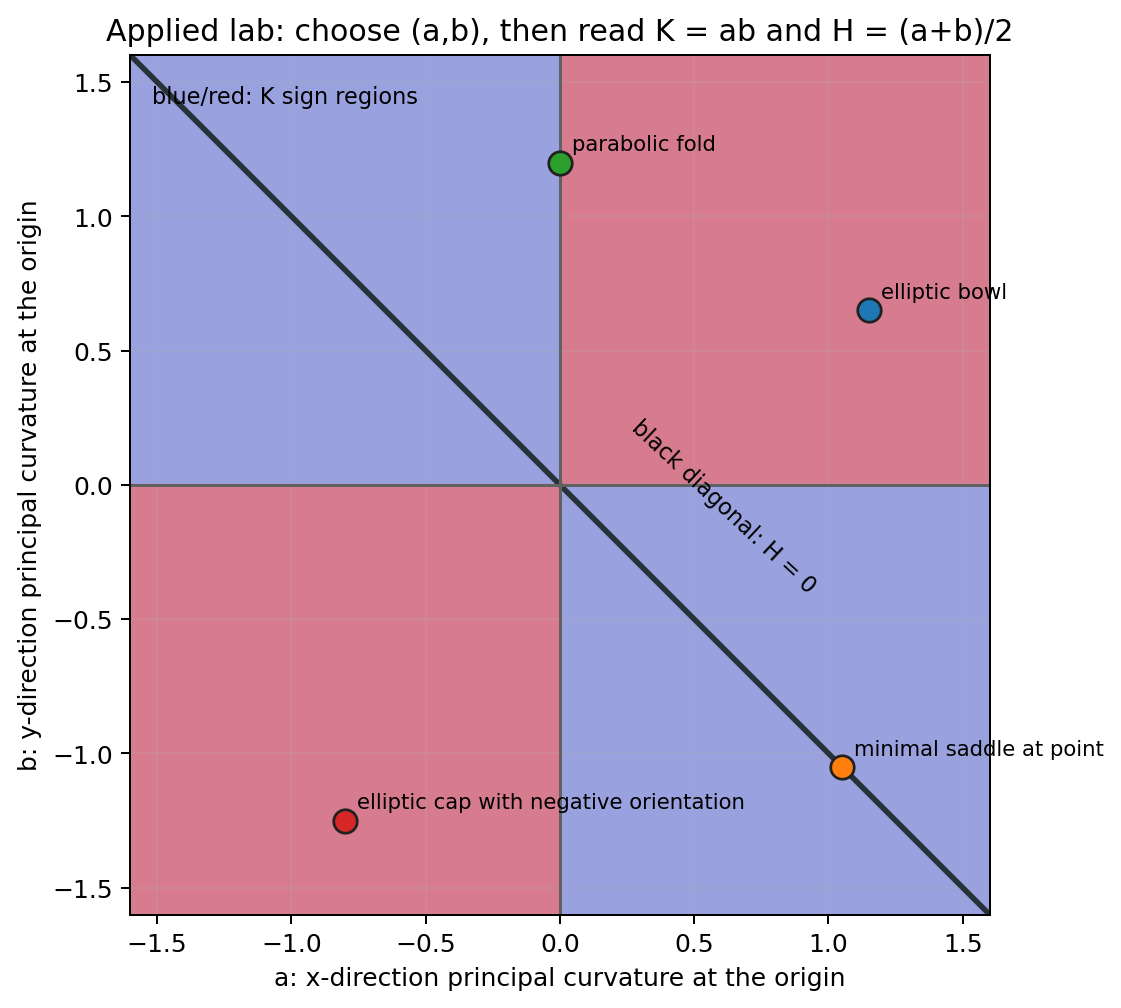

,case,a,b,K,H,classification
0,elliptic bowl,1.15,0.65,0.7475,0.900,elliptic
1,minimal saddle at point,1.05,-1.05,-1.1025,0.000,hyperbolic
2,parabolic fold,0.00,1.20,0.0000,0.600,parabolic/planar
3,elliptic cap with negative orientation,-0.80,-1.25,1.0000,-1.025,elliptic


In [10]:
a_vals = np.linspace(-1.6, 1.6, 320)
b_vals = np.linspace(-1.6, 1.6, 320)
AA, BB = np.meshgrid(a_vals, b_vals, indexing="xy")
K_design = AA * BB
H_design = (AA + BB) / 2
fig, ax = plt.subplots(figsize=(7.2, 6.2))
ax.imshow(
    np.sign(K_design),
    origin="lower",
    extent=[a_vals.min(), a_vals.max(), b_vals.min(), b_vals.max()],
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    alpha=0.52,
    aspect="equal",
)
ax.contour(AA, BB, H_design, levels=[0], colors="#263238", linewidths=2.2)
ax.axhline(0, color="#616161", lw=1.2)
ax.axvline(0, color="#616161", lw=1.2)
lab_points = pd.DataFrame([
    {"case": "elliptic bowl", "a": 1.15, "b": 0.65},
    {"case": "minimal saddle at point", "a": 1.05, "b": -1.05},
    {"case": "parabolic fold", "a": 0.0, "b": 1.2},
    {"case": "elliptic cap with negative orientation", "a": -0.8, "b": -1.25},
])
for idx, row in lab_points.iterrows():
    Kp = row["a"] * row["b"]
    Hp = (row["a"] + row["b"]) / 2
    ax.scatter(row["a"], row["b"], s=88, edgecolor="#212121", linewidth=1.1, zorder=5)
    ax.text(row["a"] + 0.045, row["b"] + 0.045, row["case"], fontsize=8.5)
    lab_points.loc[idx, "K"] = Kp
    lab_points.loc[idx, "H"] = Hp
    lab_points.loc[idx, "classification"] = "elliptic" if Kp > 0 else "hyperbolic" if Kp < 0 else "parabolic/planar"
ax.set_title("Applied lab: choose (a,b), then read K = ab and H = (a+b)/2")
ax.set_xlabel("a: x-direction principal curvature at the origin")
ax.set_ylabel("b: y-direction principal curvature at the origin")
ax.text(-1.52, 1.42, "blue/red: K sign regions", fontsize=9)
ax.text(0.25, -0.40, "black diagonal: H = 0", fontsize=9, rotation=-43)
ax.grid(alpha=0.18)
lab_fig_path = save_mpl(
    fig,
    FIG_DIR / "applied-lab-curvature-design-board.png",
    "applied_lab_design_board",
    "Design-plane lab for choosing local graph principal curvatures and reading K and H.",
)
lab_table_path = save_table(
    lab_points,
    TABLE_DIR / "applied-lab-graph-family.csv",
    "applied_lab_table",
    "CSV of applied-lab graph parameters, K, H, and local classification.",
)
lab_checks = {
    "family": "z = (a*x^2 + b*y^2)/2 at the origin",
    "rules": {"K": "a*b", "H": "(a+b)/2"},
    "cases": lab_points.to_dict(orient="records"),
    "minimal_saddle_has_zero_H_and_negative_K": bool((lab_points.loc[lab_points["case"] == "minimal saddle at point", "H"].iloc[0] == 0) and (lab_points.loc[lab_points["case"] == "minimal saddle at point", "K"].iloc[0] < 0)),
}
lab_check_path = write_json(
    CHECK_DIR / "applied-lab-curvature-family.json",
    lab_checks,
    "applied_lab_checks",
    "Checks for graph-family curvature design lab.",
)

display_artifact(lab_fig_path, width=720)
display(lab_points)


## Final Sanity Checks

The notebook closes by auditing its own claims. The checks below assert that every generated artifact exists and has content, that symbolic identities are exact where they should be exact, and that numeric residuals for the Gauss-map area ratio, self-adjointness, vector-field asymptotic directions, straight rulings, and minimal examples are within tolerance.


In [11]:
# Bring check data together from the cells above.
all_artifacts_before_final = dict(artifact_registry)
for key, path in all_artifacts_before_final.items():
    assert_artifact(path, min_bytes=64)

assert symbolic_checks["K_equals_det_S"] == "True"
assert symbolic_checks["H_equals_half_trace_S"] == "True"
assert abs(torus_checks["max_abs_signed_area_identity"]) < 1e-12
assert abs(coordinate_checks["self_adjoint_residual_max_abs"]) < 1e-12
assert abs(coordinate_checks["metric_orthogonality_for_distinct_eigenvectors"]) < 1e-12
assert abs(vector_checks["asymptotic_II_residual"]) < 1e-12
assert ruled_minimal_checks["hyperbolic_paraboloid_ruling_second_difference_max"] < 1e-12
assert ruled_minimal_checks["catenoid_max_abs_H_formula"] < 1e-12
assert ruled_minimal_checks["helicoid_max_abs_H_formula"] < 1e-12
assert lab_checks["minimal_saddle_has_zero_H_and_negative_K"]

final_sanity = {
    "chapter": "Chapter 03: The Geometry of the Gauss Map",
    "source_span": {"printed_pages": "136-219", "pdf_pages": "152-235"},
    "storyboard_items_implemented": [
        "Gauss map as signed area-distortion sensor on a torus",
        "Shape operator and principal directions on a graph saddle",
        "Dupin indicatrix for elliptic, hyperbolic, and parabolic points",
        "Vector-field views for principal and asymptotic curve nets",
        "Coordinate matrix ledger for K, H, self-adjointness, and principal curvatures",
        "Ruled/minimal comparison using hyperbolic paraboloid, catenoid, and helicoid",
        "Applied lab for designing local curvature by graph parameters",
    ],
    "artifact_count_before_final": len(all_artifacts_before_final),
    "artifact_paths": {key: book_relative(path) for key, path in sorted(all_artifacts_before_final.items())},
    "numeric_checks": {
        "torus_area_identity_max_abs": torus_checks["max_abs_signed_area_identity"],
        "coordinate_self_adjoint_residual": coordinate_checks["self_adjoint_residual_max_abs"],
        "coordinate_metric_orthogonality": coordinate_checks["metric_orthogonality_for_distinct_eigenvectors"],
        "asymptotic_II_residual": vector_checks["asymptotic_II_residual"],
        "ruled_line_second_difference": ruled_minimal_checks["hyperbolic_paraboloid_ruling_second_difference_max"],
        "catenoid_max_abs_H": ruled_minimal_checks["catenoid_max_abs_H_formula"],
        "helicoid_max_abs_H": ruled_minimal_checks["helicoid_max_abs_H_formula"],
    },
    "symbolic_checks": symbolic_checks,
    "libraries_used": {
        "numpy": "sampled surface arrays and invariant residuals",
        "matplotlib": "durable 2D/3D static figures and proof diagrams",
        "plotly": "interactive 3D surface and Gauss-map inspection artifacts",
        "sympy": "exact graph-model curvature identities",
        "networkx": "self-adjoint proof dependency scaffold",
        "pandas": "curvature ledgers and applied-lab tables",
    },
}
final_path = write_json(
    CHECK_DIR / "final-sanity.json",
    final_sanity,
    "final_sanity",
    "Final artifact, symbolic, numeric, and storyboard sanity ledger.",
)
assert_artifact(final_path, min_bytes=512)

final_sanity["artifact_count_including_final"] = len(artifact_registry)
final_sanity["final_sanity_path"] = book_relative(final_path)
final_path.write_text(json.dumps(final_sanity, indent=2, sort_keys=True), encoding="utf-8")

for key, path in artifact_registry.items():
    assert_artifact(path, min_bytes=64)

final_sanity


{'chapter': 'Chapter 03: The Geometry of the Gauss Map',
 'source_span': {'printed_pages': '136-219', 'pdf_pages': '152-235'},
 'storyboard_items_implemented': ['Gauss map as signed area-distortion sensor on a torus',
  'Shape operator and principal directions on a graph saddle',
  'Dupin indicatrix for elliptic, hyperbolic, and parabolic points',
  'Vector-field views for principal and asymptotic curve nets',
  'Coordinate matrix ledger for K, H, self-adjointness, and principal curvatures',
  'Ruled/minimal comparison using hyperbolic paraboloid, catenoid, and helicoid',
  'Applied lab for designing local curvature by graph parameters'],
 'artifact_count_before_final': 18,
 'artifact_paths': {'applied_lab_checks': 'artifacts/chapter-03/checks/applied-lab-curvature-family.json',
  'applied_lab_design_board': 'artifacts/chapter-03/figures/applied-lab-curvature-design-board.png',
  'applied_lab_table': 'artifacts/chapter-03/tables/applied-lab-graph-family.csv',
  'coordinate_shape_checks

## Takeaways

- The Gauss map turns the normal field into a measurable map to the unit sphere; Gaussian curvature is the signed local area ratio of that map.
- The shape operator `S = -dN` is the tangent-plane object behind the chapter: its determinant is `K`, its half-trace is `H`, and its eigenvectors are principal directions.
- The self-adjoint property is what makes principal directions geometrically usable: distinct principal directions are orthogonal for the surface metric.
- Vector fields turn curvature directions into curve nets, including principal curves and asymptotic curves.
- Ruled, developable, and minimal surfaces answer different questions. A surface may contain straight lines and still have negative `K`; a surface may have `H = 0` and still bend strongly.
